# Pulse arrival times from the Crab pulsar
## Crab Pulsar Experiment Part 3.2

Use this notebook as a template for Part 3.2 of the Crab pulsar experiment.

In [67]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np

# The interpolate library from scipy includes powerful interpolation routines
# including the Lagrange interpolation described in the lab script.
from scipy import interpolate

# Astropy provides many useful tools...
from astropy import coordinates as coord
from astropy import units as u
from astropy import constants as const
from astropy import time as astrotime

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from math import pi

from astropy.time import Time
import astropy.units as u
from datetime import datetime

## Load Data
Here we load your ToA data as well as the file containing solar system barycentre coordinates.

In [68]:
import numpy as np
#filepath = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/New/20260303_113724_B0531+21.npz"
filepath = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/New/20260217_143556_B0531+21.npz"

data = np.load(filepath, allow_pickle=True)

print(data.files)   # shows what's inside the npz
print(data['times'])

['times', 'freqs', 'cfreq', 'bw', 'data', 'approx_period', 'header', 'source_name']
[61088.6096061  61088.61180509 61088.61412005 61088.61643463
 61088.6187496  61088.62106456 61088.62337914 61088.62569411
 61088.62800907 61088.63032404 61088.63263901 61088.63491518
 61088.63726816 61088.63958312 61088.64188477 61088.64421306
 61088.64652724 61088.64884221 61088.65208348 61088.65347214
 61088.65578672 61088.65810169 61088.66041626 61088.66273162
 61088.6650458  61088.66736077 61088.66961775 61088.67199031
 61088.67430528 61088.67658146 61088.67910841 61088.68124979
 61088.68356437 61088.68587934 61088.68819391 61088.69050888]


In [69]:
print(data['header'])

Filename                      : 20260217_143556_B0531+21.clng
Source Name                   : B0531+21
Number of channels            : 40
Number of phase bins          : 1024
Number of sub-integrations    : 36
Centre Freq (MHz)             : 611.0
Bandwidth (MHz)               : 10.0
Integration Time (s)          : 7196.999708
Telescope                     : Jodrell


In [70]:

import os
import numpy as np

basepath = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs"

npzfile  = os.path.join(basepath+"/New", "20260217_143556_B0531+21.npz")
baryfile = os.path.join(basepath, "2026_ssb.txt")

# Load barycentre file (text)
year, month, day, xpos, ypos, zpos = np.loadtxt(baryfile, unpack=True)

# Load pulsar observation (binary npz)
obs = np.load(npzfile, allow_pickle=True)

print("Loaded npz keys:", obs.files)
print("source_name:", obs["source_name"])
print("approx_period:", obs["approx_period"])
print("data shape:", obs["data"].shape)

print("Using baryfile:", baryfile)

Loaded npz keys: ['times', 'freqs', 'cfreq', 'bw', 'data', 'approx_period', 'header', 'source_name']
source_name: B0531+21
approx_period: 0.03385139
data shape: (36, 40, 1024)
Using baryfile: /Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/2026_ssb.txt


## Compute the Earth delay

This is the delay due to the fact that the observatory is not at the centre of the Earth. For this, you need to know the elevation angle above the horizon (see the lab script for more details).

The [Astropy](http://www.astropy.org/) library provides very powerful tools to do things like coordinate transforms. Here we want to convert from equitorial (RA and Dec) coordinate system to an observatory-based [AltAz](http://docs.astropy.org/en/stable/api/astropy.coordinates.AltAz.html) coordinate system. Make sure you are familiar with these two coordinate systems. The conversion from one to the other requries knowing the location of your telecsope and also the time the observations were taken.

The following libraries have been imported for your convinience:
 * ``astropy.coordinate`` has been imported as ``coord``
 * ``astropy.time`` has been imported as ``astrotime``
 

In [71]:
from astropy.coordinates import EarthLocation

# Insert the position of the crab pulsar here!


# Jodrell Bank 42-ft telescope approximate location
JBpos = EarthLocation(
    lat=53.2359065 * u.deg,
    lon=-2.3064801 * u.deg,
    height=80*u.m)

pulsarpos = coord.SkyCoord(
    ra="05:34:31.97",
    dec="+22:00:52.1",
    unit=(u.hourangle, u.deg)
)


In [72]:
import numpy as np
from astropy.time import Time
import astropy.units as u

# Path to your saved ToA file
#toa_file = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/New/B0531+21_20260303_toas.txt"
toa_file = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/New/B0531+21_toas.txt"

# Load file (ignore lines starting with #)
data = np.loadtxt(toa_file)

# First column = MJD
toa_mjd = data[:, 0]

# Second column = uncertainty (seconds)
toa_err_sec = data[:, 1]

print("Loaded", len(toa_mjd), "ToAs")
print("First ToA:", toa_mjd[0], "±", toa_err_sec[0], "sec")

# Create astropy Time object (topocentric times at telescope)
times = Time(toa_mjd, format="mjd", scale="utc", location=JBpos)

print("Time object created successfully.")

Loaded 36 ToAs
First ToA: 61088.609606118735 ± 5.978472e-05 sec
Time object created successfully.


In [73]:
times = Time(toa_mjd, format="mjd", scale="utc", location=JBpos)


# Start of observation
#start_time = Time("2026-03-03 11:37:24", format="iso", scale="utc")
start_time = Time("2026-02-17 14:35:56", format="iso", scale="utc")

#integration_time = 18148.999708 * u.s
integration_time = 7196.999708 * u.s
mid_time = start_time + integration_time / 2




bary_datetimes = [datetime(int(y), int(m), int(d), 0, 0, 0) for y, m, d in zip(year, month, day)]
bary_mjd = Time(bary_datetimes, scale="utc").mjd



In [74]:
print("toa_mjd range:", toa_mjd.min(), "to", toa_mjd.max())
print("bary_mjd range:", bary_mjd.min(), "to", bary_mjd.max())


toa_mjd range: 61088.609606118735 to 61088.69050889372
bary_mjd range: 61041.0 to 61405.0


In [75]:

# To compute the angle between the pulsar and the earth we can use astropy to tell us the elevation angle to the pulsar.
# First Transform the coordinate system to an Alt-Az system. This needs the location of the telescope and the times
# of the observation.
# altaz = pulsarpos.transform_to(coord.AltAz(obstime=times,location=lovellpos))

altaz = pulsarpos.transform_to(coord.AltAz(obstime=times, location=JBpos))
elevation = altaz.alt.to(u.rad).value
# earth_delay = ...

R_earth = 6371000.0  # m (good enough)
c = 299792458.0      # m/s

earth_delay_sec = (R_earth * np.sin(elevation)) / c
earth_delay_days = earth_delay_sec / 86400.0
toa_geo_mjd = toa_mjd + earth_delay_days

print("Earth-telescope delay range (sec):",
      earth_delay_sec.min(), "to", earth_delay_sec.max())
print(earth_delay_sec.min()-earth_delay_sec.max())

Earth-telescope delay range (sec): 0.008577603370515812 to 0.013951826089583366
-0.0053742227190675534


## Compute the Roemer delay

This is the delay corresponding to the distance of the centre of the Earth to the barycentre.


In [76]:
x_interp = np.interp(toa_geo_mjd, bary_mjd, xpos)
y_interp = np.interp(toa_geo_mjd, bary_mjd, ypos)
z_interp = np.interp(toa_geo_mjd, bary_mjd, zpos)


pulsarpos = coord.SkyCoord(
    ra="05:34:31.97",
    dec="+22:00:52.1",
    unit=(u.hourangle, u.deg)
)

# psr_x = ...
# psr_y = ...
# psr_z = ...
# Unit vector toward pulsar
psr_x = pulsarpos.cartesian.x.value
psr_y = pulsarpos.cartesian.y.value
psr_z = pulsarpos.cartesian.z.value
# roemer_delay = ...

# Dot product r · n
c = 299792458.0
AU_m = 1.495978707e11

roemer_delay_sec = (x_interp * psr_x + y_interp * psr_y + z_interp * psr_z) * (AU_m / c)
roemer_delay_days = roemer_delay_sec / 86400.0

toa_bary_mjd = toa_geo_mjd + roemer_delay_days

print("Roemer delay range (sec):", roemer_delay_sec.min(), "to", roemer_delay_sec.max(),"\ndifference: ",-roemer_delay_sec.min()+ roemer_delay_sec.max())



Roemer delay range (sec): 208.891151233008 to 209.52115257335717 
difference:  0.6300013403491675


In [77]:
print("Roemer delay range (sec):",
      roemer_delay_sec.min(), "to", roemer_delay_sec.max())

Roemer delay range (sec): 208.891151233008 to 209.52115257335717


In [78]:
print("total correction: ", toa_bary_mjd.min(),'to',toa_bary_mjd.max())
print("the difference: ", toa_bary_mjd.max()-toa_bary_mjd.min())

total correction:  61088.61203123136 to 61088.69292677686
the difference:  0.08089554549951572


## Residuals from a fixed period model



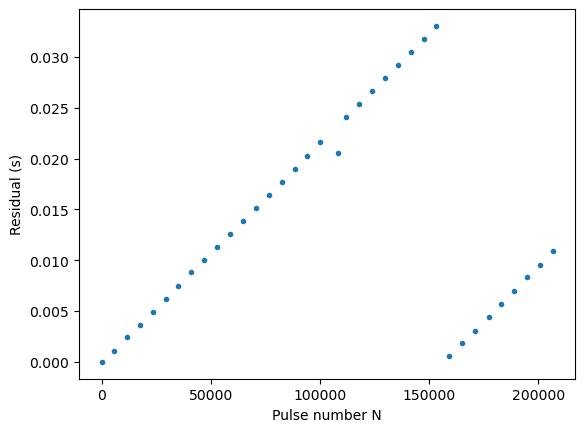

In [79]:
# The data file includes a sutiable 'guess period' as described in the lab script.
# You can either load the data file or get it from the 'Make Time of Arrivals' notebook.
period_guess = float(obs["approx_period"])

t_sec = (toa_bary_mjd - toa_bary_mjd[0]) * 86400.0

N = (t_sec / period_guess).astype(int)
# residual = 

residual_sec = t_sec - N * period_guess

plt.plot(N, residual_sec, ".")
plt.xlabel("Pulse number N")
plt.ylabel("Residual (s)")
plt.show()
# Do fitting (try the polyfit routine in numpy)

In [80]:
print("Earth-site delay range (sec):", earth_delay_sec.min(), earth_delay_sec.max(),"\nthe difference: ",-earth_delay_sec.min()+earth_delay_sec.max() )
print("Roemer delay range (sec):", roemer_delay_sec.min(), roemer_delay_sec.max(),"\nthe difference: ",-roemer_delay_sec.min()+ roemer_delay_sec.max() )


Earth-site delay range (sec): 0.008577603370515812 0.013951826089583366 
the difference:  0.0053742227190675534
Roemer delay range (sec): 208.891151233008 209.52115257335717 
the difference:  0.6300013403491675


Period guess = 0.03385139 s
Slope b      = 2.1678853263196055e-07 s/pulse
Best period  = 0.033851606788532634 s


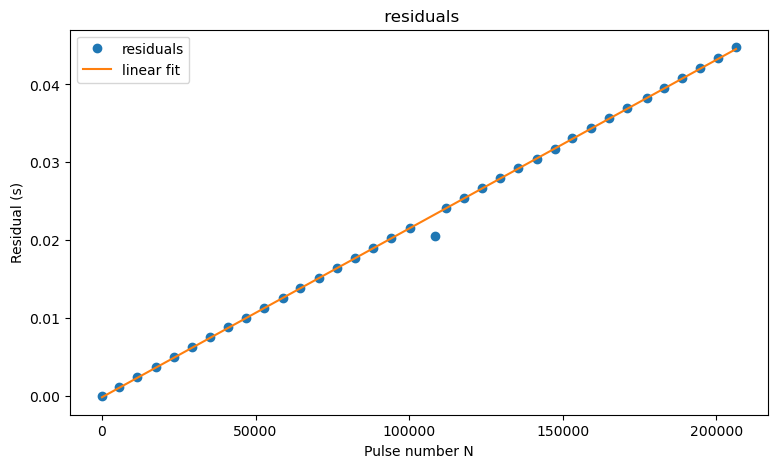

In [81]:
import numpy as np
import matplotlib.pyplot as plt



# use barycentric ToAs
t_sec = (toa_bary_mjd - toa_bary_mjd[0]) * 86400.0

# pulse number
N = np.rint(t_sec / period_guess).astype(int)

# wrapped residuals in [0, P)
residual_sec = t_sec - N * period_guess
residual_sec = residual_sec % period_guess

# ---- unwrap residuals ----
residual_unwrapped = residual_sec.copy()

for i in range(1, len(residual_unwrapped)):
    jump = residual_unwrapped[i] - residual_unwrapped[i - 1]

    if jump > 0.5 * period_guess:
        residual_unwrapped[i:] -= period_guess
    elif jump < -0.5 * period_guess:
        residual_unwrapped[i:] += period_guess

# fit straight line to unwrapped residuals
b, a = np.polyfit(N, residual_unwrapped, 1)
P_fit = period_guess + b

print("Period guess =", period_guess, "s")
print("Slope b      =", b, "s/pulse")
print("Best period  =", P_fit, "s")



plt.figure(figsize=(9,5))
plt.plot(N, residual_unwrapped, "o", label="residuals")
plt.plot(N, a + b*N, "-", label="linear fit")
plt.xlabel("Pulse number N")
plt.ylabel("Residual (s)")
plt.title(" residuals")
plt.legend()
plt.show()

In [82]:
# linear fit with covariance
p, cov = np.polyfit(N, residual_unwrapped, 1, cov=True)

b = p[0]
a = p[1]

sigma_b = np.sqrt(cov[0,0])   # uncertainty on slope

P_fit = period_guess + b
sigma_P = sigma_b

print("Best period =", P_fit, "s")
print("Uncertainty =", sigma_P, "s")

Best period = 0.033851606788532634 s
Uncertainty = 1.3238654806228375e-09 s


Number of valid points: 36
sigma range: 3.440478e-05 to 7.635803e-05
Best period = 0.033851606882858 s
Uncertainty = 8.347e-10 s
chi^2 = 1717.024
Degrees of freedom = 34
Reduced chi^2 = 50.501


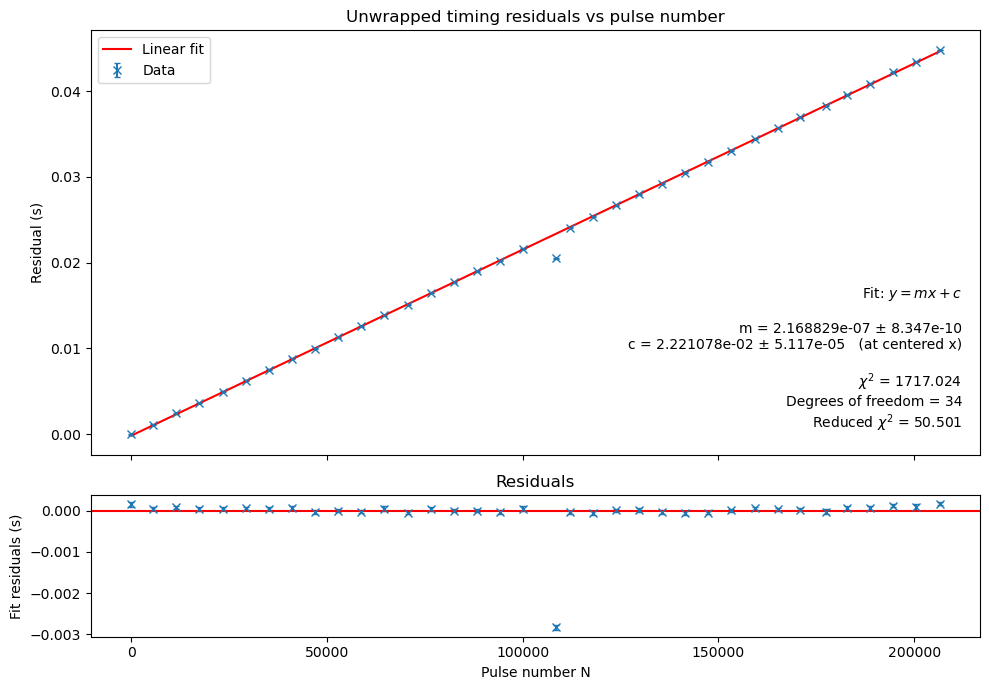

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Build clean arrays
# ----------------------------
x = np.asarray(N, dtype=float)
y = np.asarray(residual_unwrapped, dtype=float)
sigma = np.asarray(toa_err_sec, dtype=float)

# keep only valid points
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)

x = x[mask]
y = y[mask]
sigma = sigma[mask]

print("Number of valid points:", len(x))
print("sigma range:", sigma.min(), "to", sigma.max())

# center x to improve numerical stability
x0 = x.mean()
x_cent = x - x0

# ----------------------------
# Weighted linear fit: y = m*(x-x0) + c0
# ----------------------------
p, cov = np.polyfit(x_cent, y, 1, w=1/sigma, cov=True)

m, c0 = p
sigma_m = np.sqrt(cov[0, 0])
sigma_c0 = np.sqrt(cov[1, 1])

# fitted model in centered coordinates
y_fit = m * x_cent + c0

# chi-squared
chi2 = np.sum(((y - y_fit) / sigma) ** 2)
dof = len(x) - 2
chi2_red = chi2 / dof

# corrected period and uncertainty
P_fit = period_guess + m
sigma_P = sigma_m

print(f"Best period = {P_fit:.15f} s")
print(f"Uncertainty = {sigma_P:.3e} s")
print(f"chi^2 = {chi2:.3f}")
print(f"Degrees of freedom = {dof}")
print(f"Reduced chi^2 = {chi2_red:.3f}")

# residuals about fitted line
fit_resid = y - y_fit

# ----------------------------
# Plot
# ----------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax1.errorbar(x, y, yerr=sigma, fmt='x', capsize=2, label='Data')
ax1.plot(x, y_fit, 'r-', label='Linear fit')

ax1.set_ylabel("Residual (s)")
ax1.set_title("Unwrapped timing residuals vs pulse number")

fit_text = (
    "Fit: $y = mx + c$\n\n"
    f"m = {m:.6e} ± {sigma_m:.3e}\n"
    f"c = {c0:.6e} ± {sigma_c0:.3e}   (at centered x)\n\n"
    f"$\\chi^2$ = {chi2:.3f}\n"
    f"Degrees of freedom = {dof}\n"
    f"Reduced $\\chi^2$ = {chi2_red:.3f}"
)

ax1.text(
    0.98, 0.05, fit_text,
    transform=ax1.transAxes,
    ha='right', va='bottom',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none')
)

ax1.legend()

ax2.errorbar(x, fit_resid, yerr=sigma, fmt='x', capsize=2)
ax2.axhline(0, color='r')
ax2.set_xlabel("Pulse number N")
ax2.set_ylabel("Fit residuals (s)")
ax2.set_title("Residuals")

plt.tight_layout()
plt.show()

Initial number of points: 36
Removed outliers: 1
Remaining points: 35

Best period = 0.033851606965422 s
Uncertainty = 9.394e-11 s
chi^2 = 20.446
Degrees of freedom = 32
Reduced chi^2 = 0.639


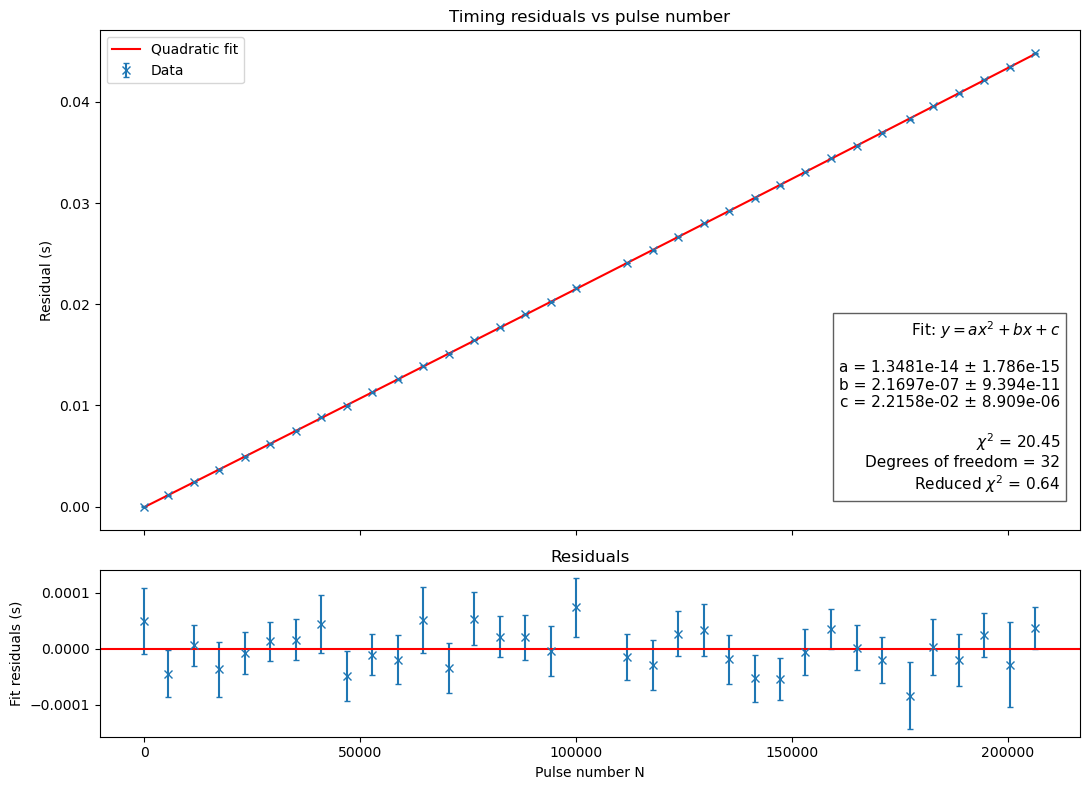

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Build clean arrays
# ----------------------------
x = np.asarray(N, dtype=float)
y = np.asarray(residual_unwrapped, dtype=float)
sigma = np.asarray(toa_err_sec, dtype=float)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma) & (sigma > 0)
x = x[mask]
y = y[mask]
sigma = sigma[mask]

print("Initial number of points:", len(x))

# center x for numerical stability
x0 = x.mean()
x_cent = x - x0

# ----------------------------
# First quadratic fit
# ----------------------------
p, cov = np.polyfit(x_cent, y, 2, w=1/sigma, cov=True)
a2, b2, c0 = p

y_fit = a2 * x_cent**2 + b2 * x_cent + c0
fit_resid = y - y_fit

# ----------------------------
# Sigma clipping
# ----------------------------
clip_level = 5   # 5-sigma clipping
good = np.abs(fit_resid) < clip_level * sigma

print("Removed outliers:", np.sum(~good))
print("Remaining points:", np.sum(good))

# apply mask
x_clean = x[good]
y_clean = y[good]
sigma_clean = sigma[good]

# re-center after clipping
x0 = x_clean.mean()
x_cent_clean = x_clean - x0

# ----------------------------
# Refit quadratic on cleaned data
# ----------------------------
p, cov = np.polyfit(x_cent_clean, y_clean, 2, w=1/sigma_clean, cov=True)
a2, b2, c0 = p

sigma_a2 = np.sqrt(cov[0, 0])
sigma_b2 = np.sqrt(cov[1, 1])
sigma_c0 = np.sqrt(cov[2, 2])

y_fit_clean = a2 * x_cent_clean**2 + b2 * x_cent_clean + c0
fit_resid_clean = y_clean - y_fit_clean

# ----------------------------
# Fit statistics
# ----------------------------
chi2 = np.sum(((y_clean - y_fit_clean) / sigma_clean) ** 2)
dof = len(x_clean) - 3
chi2_red = chi2 / dof

P_fit = period_guess + b2
sigma_P = sigma_b2

print(f"\nBest period = {P_fit:.15f} s")
print(f"Uncertainty = {sigma_P:.3e} s")
print(f"chi^2 = {chi2:.3f}")
print(f"Degrees of freedom = {dof}")
print(f"Reduced chi^2 = {chi2_red:.3f}")

# ----------------------------
# Plot like your screenshot
# ----------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# top panel
ax1.errorbar(x_clean, y_clean, yerr=sigma_clean, fmt='x', capsize=2, label='Data')
ax1.plot(x_clean, y_fit_clean, 'r-', label='Quadratic fit')

ax1.set_ylabel("Residual (s)")
ax1.set_title("Timing residuals vs pulse number")
ax1.legend(loc="upper left")

fit_text = (
    "Fit: $y = ax^2 + bx + c$\n\n"
    f"a = {a2:.4e} ± {sigma_a2:.3e}\n"
    f"b = {b2:.4e} ± {sigma_b2:.3e}\n"
    f"c = {c0:.4e} ± {sigma_c0:.3e}\n\n"
    f"$\\chi^2$ = {chi2:.2f}\n"
    f"Degrees of freedom = {dof}\n"
    f"Reduced $\\chi^2$ = {chi2_red:.2f}"
)

ax1.text(
    0.98, 0.07, fit_text,
    transform=ax1.transAxes,
    ha='right', va='bottom',
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='0.3')
)

# bottom panel
ax2.errorbar(x_clean, fit_resid_clean, yerr=sigma_clean, fmt='x', capsize=2)
ax2.axhline(0, color='r')

ax2.set_xlabel("Pulse number N")
ax2.set_ylabel("Fit residuals (s)")
ax2.set_title("Residuals")

plt.tight_layout()
plt.show()

In [94]:
age = 0.5*(0.033852109214379)/((0.033852109214379-0.033851606965422))*14/365
print(age,"years")

1292.6229588528936 years


In [93]:
B =3.2*10**19*np.sqrt(0.033852109214379*(0.033852109214379-0.033851606965422)/(14*24*3600)) 
print(f"B = {B:.3e} G")

B = 3.794e+12 G
